# Lab 3: Sentinel-1 Time Series for Crop Growth in Midwest Row-Crop Fields

This notebook is for a lab on seasonal crop growth using Sentinel-1 SAR backscatter in large Midwestern U.S. fields.

The lab is designed to stay fully in Google Earth Engine + Python. We will be:

- building a consistent Sentinel-1 time series,
- selecting individual row-crop fields, forested regions, and towns/cities,
- extracting field-scale backscatter statistics,
- comparing seasonal trajectories,
- proposing a simple crop growth metric based on VV, VH, or VV/VH.

---

## Lab concept

Students will:

1. choose several individual regions in a Midwest US AOI. You do not have to choose a midwest US AOI, but it will be the easiest. Midwest US/Canada has perfectly North/South Aligned farms in 1.5 km grids, which uniformly grow corn/wheat/soy/etc. European farms are much smaller, and randomly oriented. Averaging over an entire field will increase the signal to noise ratio.
2. define field polygons as regions of interest,
3. build a seasonal Sentinel-1 time series,
4. compute field-level summary statistics for:
   - VV
   - VH
   - VV - VH (in dB is a convenient proxy related to VV/VH ratio)
5. interpret how those quantities evolve from:
   - bare ground / early season
   - vegetative growth
   - maturity
   - senescence (interesting fact - senescence progression is monitored via NDVI)
   - harvest

---

## Why the Midwest U.S.?

This is a good teaching region because many fields are:

- large,
- homogeneous,
- easy to outline,
- minimally affected by complex topography,
- dominated by row crops with strong seasonal structure.

That makes field-scale SAR time series much easier to interpret than small, irregular fields. Irregularly oriented fields produce an additional complexity with regards to geometry. You may have noticed when exploring Krakow SAR that the backscatter from farms could vary greatly. This can be due to differences in crop type, but it can also be related to how the rows are oriented with respect to the satellite look direction. Think about the ground texture of farms, there are many small ridges and valleys. If these ridges and valleys are parallel to the satellite look direction, backscatter will be weaker, and if the ridges and valleys are perpendicular to the satellite look direction, backscatter will be stronger.

---

## learning goals

By the end of this lab, students should be able to:

- explain why SAR time series must be filtered consistently,
- compute a field-averaged VV and VH time series,
- compare crop fields with a non-crop control,
- propose and defend simple crop growth metrics,
- explain why VH or VV-VH may respond differently from VV alone.

---

## 1. Imports and Earth Engine initialization

This notebook assumes that students already have:

- a working Python environment,
- the Earth Engine Python API,
- `geemap`,
- libraries `matplotlib` and `pandas`.

In [1]:
import ee
import geemap
import pandas as pd
import json
import matplotlib.pyplot as plt

PROJECT_ID = "commanding-air-494108-v2"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine initialized.")


Successfully saved authorization token.
Earth Engine initialized.


## 2. Define an agricultural AOI

This notebook starts with a large AOI in northern Iowa / southern Minnesota.  
You can adjust it later, but it is helpful to begin with a region dominated by large row-crop fields. In one scene, I want you to find a place that has:

- individual crop fields that you can isolate
- A city or town that we're not expecting a strong vegetative growth signal from
- a stand of trees you can isolate

**QUESTION (5pts): Why is the subregion you chose a good choice for exploring crop growth? Trees and crops both have vegetative growth during summer months, but what differences would you expect to see over a year, with regards to VV, VH, and VV-VH? What do you expect to see in the city or town that you have isolated?**

**ANSWER:**

Over a year, crop fields will show dramatic seasonal variability in radar backscatter. In spring, the signal is dominated by surface scattering from bare soil, resulting in lower VH and a high VV-VH difference. As the crops grow during the summer, the developing canopy triggers intense volume scattering, which causes a sharp increase in VH and a corresponding drop in the VV-VH ratio, before dropping abruptly back to baseline levels after the autumn harvest.

Despite vegetation, the trees are far more stable target. While they experience a slight peak in VH volume scattering during full-leaf conditions, the underlying structure of trunks and branches ensures that both VV and VH remain consistently high and stable throughout the year, with a much flatter VV-VH trend compared to the agricultural fields.

The city or town will display a completely different radar signature characterized by high and flat backscatter values in both VV and VH polarizations. This is caused by double-bounce scattering from the right angles of building walls and paved streets.

In [2]:
# Example AOI: large row-crop region in northern Iowa / southern Minnesota
aoi = ee.Geometry.Rectangle([-93.95, 43.65, -93.25, 44.15])

# Growing season year
YEAR = 2025

# Visualization parameters
vv_vis = {"min": -18, "max": 2}
vh_vis = {"min": -28, "max": -8}
ratio_vis = {"min": 2, "max": 12}

m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.addLayer(aoi, {"color": "red"}, "AOI")
m

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## 3. Helper functions

To keep the notebook readable, the repetitive Earth Engine logic is collected into helper functions.

These functions do most of the work for:

- building a filtered Sentinel-1 collection,
- creating monthly composites,
- computing a convenient VV-VH metric,
- extracting region statistics through time.

---

### Why use `VV - VH` here?

Sentinel-1 GRD backscatter in Earth Engine is in dB.  
So for this lab, instead of using a raw linear ratio `VV/VH`, we use:

\[
VV - VH
\]

because in dB space this is directly related to the log-ratio and is easier to interpret consistently alongside VV and VH.


In [3]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass="ASCENDING",
                      mode="IW",
                      resolution=10):
    """Return a filtered Sentinel-1 GRD collection with VV and VH."""
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq("instrumentMode", mode))
        .filter(ee.Filter.eq("orbitProperties_pass", orbit_pass))
        .filter(ee.Filter.eq("resolution_meters", resolution))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .select(["VV", "VH"])
    )
    return collection


def monthly_composite(year, month, region=aoi):
    """Return a monthly median Sentinel-1 image with a derived VV-VH band."""
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    collection = get_s1_collection(start, end, region=region)
    image = collection.median().clip(region)

    vv_minus_vh = image.select("VV").subtract(image.select("VH")).rename("VV_minus_VH")

    return (
        image.addBands(vv_minus_vh)
        .set({
            "year": year,
            "month": month,
            "system:time_start": start.millis(),
            "scene_count": collection.size()
        })
    )


def build_monthly_stack(year, months=range(3, 11), region=aoi):
    """Create a monthly ImageCollection for a growing season."""
    images = [monthly_composite(year, month, region=region) for month in months]
    return ee.ImageCollection(images)


def region_time_series(image_collection, region, scale=10):
    """Extract field-level mean VV, VH, and VV_minus_VH through time.

    Accepts either an ee.Geometry or an ee.Feature.
    """
    # If region is a Feature, convert it to its geometry
    if isinstance(region, ee.feature.Feature):
        region = region.geometry()

    def per_image(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=scale,
            maxPixels=1e9,
            bestEffort=True
        )
        return ee.Feature(None, {
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
            "year": img.get("year"),
            "month": img.get("month"),
            "scene_count": img.get("scene_count"),
            "VV": stats.get("VV"),
            "VH": stats.get("VH"),
            "VV_minus_VH": stats.get("VV_minus_VH")
        })

    return ee.FeatureCollection(image_collection.map(per_image))

def fc_to_df(fc):
    """Convert an Earth Engine FeatureCollection of stats into a pandas DataFrame."""
    data = fc.getInfo()["features"]
    rows = [f["properties"] for f in data]
    df = pd.DataFrame(rows)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values("date").reset_index(drop=True)
    return df


## 4. Build a seasonal Sentinel-1 time series

We build monthly median images from February through November.

**QUESTION (5pts): What are the advantages and disadvantages of using monthly median stacks instead of relying on single scenes? In what circumstances would you not want to do any temporal averaging, and instead rely on single scenes?**

**ANSWER:**

Using monthly median stacks removes the speckle noise and eliminates short term environmental anomalies like heavy rainfall events that temporarily spike soil moisture. Moreover, it provides a cloud-free, spatially contiguous dataset, minimizing the data gaps and extreme outliers.
However, the main disadvantage of this temporal aggregation is the loss of high-frequency temporal resolution, which smooths out rapid land-surface changes. 
Avoiding temporal averaging and rely strictly on single scenes will be useful while tracking dynamic events that require exact observation dates, such as monitoring active flood or fire events, assessing immediate post-disaster damages, as well as precisely capturing specific growth stages when mapping crops.

**QUESTION (5pts): Why do we filter Sentinel-1 by orbit direction, instrument mode, polarization, and resolution before building the time series? What might happen if ascending and descending passes were mixed in the same time series?**

**ANSWER:**

Filtering Sentinel-1 data by these parameters is crucial to ensure that we are comparing identical physical measurements, as different radar configurations change how the signal interacts with the ground and can cause data incomparability. Mixing ascending and descending passes introduces geometric distortions, such as foreshortening, layover, and shadowing, which flip orientation between orbits. As discussed in previous labs, because SAR is a side-looking sensor, viewing the same area from opposite directions creates massive artificial fluctuations.


In [4]:
months = list(range(2, 12))  # February through November
monthly_stack = build_monthly_stack(YEAR, months=months, region=aoi)

print("Monthly images in stack:", monthly_stack.size().getInfo())

# Check how many scenes contribute to each month
for month in months:
    img = monthly_composite(YEAR, month, aoi)
    print(f"Month {month:02d}: {ee.Number(img.get('scene_count')).getInfo()} scenes")


Monthly images in stack: 10
Month 02: 8 scenes
Month 03: 8 scenes
Month 04: 10 scenes
Month 05: 4 scenes
Month 06: 3 scenes
Month 07: 3 scenes
Month 08: 4 scenes
Month 09: 2 scenes
Month 10: 4 scenes
Month 11: 4 scenes


## 5. Quick visual inspection

Before drawing fields, it is useful to inspect one or two monthly composites.

Suggested things to look for:

- field texture,
- strong contrasts between different fields,
- stable non-crop controls such as roads, towns, or tree patches.

**QUESTION (10pts): Compare an early month with a peak month visually. Feel free to change the months plotted, or add in comparisons of early vs mid- season VV_minus_VH, for your investigations. Take particular note of how much VH changes vs how much VV changes. What regions do you think you will choose for your ROI's and why? If you want an extra challenge (but not necessary), try to find a field you think was tall crops, a field you think was short crops, and a field you think was left barren.**

**ANSWER:**

**VH change**
In the early season (February), fields show very low backscatter in the VH channel, making field borders invisible. This occurs because VH registers volume scattering; since the bare ground acts like a flat mirror to the radar signal, it reflects the energy away from the sensor, resulting in a very low response. During this period, towns, railway tracks, roads, and forested river valleys represent very stable features that stand out clearly against the dark background.

In mid-season (July) more fields are distinguishable, although they sometimes blend together. Changing the analysis to June seems better for field isolation because crops are at varying growth stages - early-canopy fields generate strong VH volume scattering, while slower-growing fields remain darker, creating a sharp mosaic.

**VV change**
In February the fields appear dark-grey but not completely black like in VH and the particular fields are distinguishable. Urban areas and infrastructure stand out as bright pixels, making good control points. 

In July the entire image brightens into a light-grey mosaic as crops grow. The VV channel shows much less dynamic variation between winter and summer compared to VH because it continuously registers strong surface scattering from the ground throughout the entire year.

**VV-VH ratio**
The early image is almost completely white, as it could be expected after examining previous composites. Although, it nicely shows the stable areas. It has one main advantage compared to VH backscatter - it is resistant to soil moisture and weather influence, which reduces the risk of misinterpretation. 

ROI selection:
* Crop Fields - to track and compare different crop types and their growth stages.
* Forest/Trees - the complex tree structure maintains a consistently high volume scattering (VH) signal in both winter and summer.
* Urban Areas - they serve as a static, non-vegetated control (VV).

In [18]:
img_early = monthly_composite(YEAR, 2, aoi)
img_peak = monthly_composite(YEAR, 7, aoi)
img_peak_june = monthly_composite(YEAR, 6, aoi)

#YOUR CODE HERE: The lines above grab the montlhy composite images for February and July. I want you to plot a split_map image of the VH channel in this cell, and in the cell below plot a split_map image of the VV channel for the same months.
m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VH"), vh_vis, "VH February"),
    right_layer=geemap.ee_tile_layer(img_peak_june.select("VH"), vh_vis, "VH June"),
)
display(m)
#m.addLayer(aoi, {"color": "red"}, "AOI")

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

In [20]:
#Plot the VV split_map here.

m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VV"), vv_vis, "VV February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VV"), vv_vis, "VV July")
)
display(m)

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

In [ ]:
diff_early = img_early.select("VV").subtract(img_early.select("VH")).rename("VV_minus_VH")
diff_peak = img_peak.select("VV").subtract(img_peak.select("VH")).rename("VV_minus_VH")

m_diff = geemap.Map(center=[43.9, -93.6], zoom=11)
m_diff.split_map(
    left_layer=geemap.ee_tile_layer(diff_early, ratio_vis, "Diff February"),
    right_layer=geemap.ee_tile_layer(diff_peak, ratio_vis, "Diff July")
)
display(m_diff)

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

# 6. Draw field polygons

Use the map drawing tools to create several polygons:

- at least **two different crop fields**
- at least **two control areas** (1 patch of trees, 1 city or town)

### Suggested strategy
Pick fields that are:

- large,
- internally uniform,
- clearly separated from neighboring fields.

After drawing polygons on the map, export them to Earth Engine objects.

**NOTE: You will need to remember the order of the ROI's you chose. For example, remember that you first chose three farm fields, then a tree stand, then the city/town. In the next section, you will need to assign these drawn features to variables and a dictionary.**



In [21]:
m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
m.addLayer(img_peak.select("VH"), vh_vis, "VH July")
#m.addLayer(aoi, {"color": "red"}, "AOI")
m

# After drawing polygons with the map tools, use:
# drawn_fc = m.draw_features

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [22]:
drawn_fc = m.draw_features
print(drawn_fc)

[<ee.feature.Feature object at 0x0000021AB0AA47D0>, <ee.feature.Feature object at 0x0000021AB0AA6570>, <ee.feature.Feature object at 0x0000021AB0AA6AB0>, <ee.feature.Feature object at 0x0000021AB0AA59D0>, <ee.feature.Feature object at 0x0000021AB0AA6330>, <ee.feature.Feature object at 0x0000021AB0AA5790>, <ee.feature.Feature object at 0x0000021AB0AA4050>, <ee.feature.Feature object at 0x0000021AB0AA5C10>, <ee.feature.Feature object at 0x0000021AB0AA5310>, <ee.feature.Feature object at 0x0000021AB0AA6870>]


## 7. Make sure your drawn features are where you want them.

To do this, you will need to need to adjust the code below to match the order and number of ROI's you chose to investigate.


In [23]:
# Use drawn polygons if available, otherwise fall back to example polygons.
drawn_fc = m.draw_features
features = []

if drawn_fc is not None:
    try:
        if isinstance(drawn_fc, dict) and "features" in drawn_fc:
            features = [ee.Feature(f) for f in drawn_fc["features"]]
        else:
            features = [ee.Feature(f) if not isinstance(f, ee.Feature) else f for f in drawn_fc]
    except Exception:
        features = []

if len(features) >= 10:
    field_1 = features[0]
    field_2 = features[1]
    field_3 = features[2]
    field_4 = features[3]
    field_5 = features[4]
    field_6 = features[5]
    field_7 = features[6]
    field_8 = features[7]
    trees_1 = features[8]
    control_1 = features[9]
    roi_source = "drawn"
else:
    roi_source = "fallback"
    print("Using fallback example polygons because drawn features were not available.")
    field_1 = ee.Geometry.Rectangle([-93.731, 43.949, -93.714, 43.964])
    field_2 = ee.Geometry.Rectangle([-93.666, 43.865, -93.646, 43.882])
    field_3 = ee.Geometry.Rectangle([-93.620, 43.900, -93.600, 43.917])
    # I'm just going to duplicate field_3 for the remaining fields, so that the dictionary works properly
    field_4 = field_3
    field_5 = field_3
    field_6 = field_3
    field_7 = field_3
    field_8 = field_3
    trees_1 = ee.Geometry.Rectangle([-93.585, 43.971, -93.571, 43.982])
    control_1 = ee.Geometry.Rectangle([-93.760, 43.835, -93.745, 43.845])

roi_dict = {
    "Field_1": field_1,
    "Field_2": field_2,
    "Field_3": field_3,
    "Field_4": field_4,
    "Field_5": field_5,
    "Field_6": field_6,
    "Field_7": field_7,
    "Field_8": field_8,
    "Trees_1": trees_1,
    "Control_1": control_1
}

print(f"ROI source: {roi_source}")
for name, roi in roi_dict.items():
    if isinstance(roi, ee.Geometry):
        print(name, roi.getInfo())
    elif isinstance(roi, ee.Feature):
        print(name, roi.geometry().getInfo())
    else:
        print(name, roi)

img_peak = monthly_composite(YEAR, 7, aoi)

m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)
m

ROI source: drawn
Field_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.632417, 43.866144], [-93.637483, 43.866082], [-93.637397, 43.877281], [-93.635164, 43.876972], [-93.633361, 43.875549], [-93.632245, 43.875054], [-93.632417, 43.866144]]]}
Field_2 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.637141, 43.898684], [-93.63697, 43.895344], [-93.627353, 43.895159], [-93.627439, 43.898746], [-93.637141, 43.898684]]]}
Field_3 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.306321, 44.066102], [-93.289835, 44.066226], [-93.289148, 44.072762], [-93.306149, 44.073256], [-93.306321, 44.066102]]]}
Field_4 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.802878, 43.724641], [-93.80305, 43.717383], [-93.797726, 43.717569], [-93.797898, 43.724331], [-93.802878, 43.724641]]]}
Field_5 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.923799, 44.080285], [-93.923799, 44.08719], [-93.916243, 44.087437], [-93.916243, 44.080039], [-93.92

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## 8. Extract time series for each field

For each ROI, compute a field-mean time series of:

- VV
- VH
- VV - VH

This is the core analysis step of the lab.

In [24]:
ts_dict = {}

for name, geom in roi_dict.items():
    fc = region_time_series(monthly_stack, geom, scale=10)
    df = fc_to_df(fc)
    ts_dict[name] = df

for name, df in ts_dict.items():
    print(f"\n{name} ({len(df)} monthly points)")
    display(df)

# Example access for Field_1
if "Field_1" in ts_dict:
    ts_dict["Field_1"]
else:
    print("Field_1 not found in ts_dict")


Field_1 (10 monthly points)


,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-31.974320,-18.245316,13.729004,2025-02-01,2,8,2025
1,-23.740593,-13.305163,10.435430,2025-03-01,3,8,2025
2,-28.094261,-15.505524,12.588738,2025-04-01,4,10,2025
3,-24.763165,-13.831636,10.931529,2025-05-01,5,4,2025
4,-24.900292,-13.688374,11.211919,2025-06-01,6,3,2025
5,-20.453388,-12.403006,8.050382,2025-07-01,7,3,2025
6,-16.284417,-9.518987,6.765430,2025-08-01,8,4,2025
7,-18.458087,-10.597162,7.860925,2025-09-01,9,2,2025
8,-20.273704,-10.990896,9.282808,2025-10-01,10,4,2025
9,-21.895631,-12.146241,9.749390,2025-11-01,11,4,2025



Field_2 (10 monthly points)


,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-30.802499,-18.353083,12.449416,2025-02-01,2,8,2025
1,-21.784010,-13.812369,7.971641,2025-03-01,3,8,2025
2,-23.777635,-15.241065,8.536571,2025-04-01,4,10,2025
3,-23.389087,-15.305926,8.083162,2025-05-01,5,4,2025
4,-20.604252,-14.153999,6.450252,2025-06-01,6,3,2025
5,-18.298686,-12.849438,5.449248,2025-07-01,7,3,2025
6,-18.711392,-12.962352,5.749040,2025-08-01,8,4,2025
7,-19.416111,-13.310570,6.105542,2025-09-01,9,2,2025
8,-20.312798,-13.745893,6.566904,2025-10-01,10,4,2025
9,-23.666968,-15.261921,8.405046,2025-11-01,11,4,2025



Field_3 (10 monthly points)


...

,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-30.876801,-15.794453,15.082348,2025-02-01,2,8,2025
1,-18.641316,-9.241718,9.399598,2025-03-01,3,8,2025
2,-22.324754,-11.933082,10.391672,2025-04-01,4,10,2025
3,-22.270319,-12.429589,9.840730,2025-05-01,5,4,2025
4,-22.993447,-13.538702,9.454745,2025-06-01,6,3,2025
5,-15.508865,-9.077190,6.431675,2025-07-01,7,3,2025
6,-16.469415,-9.700825,6.768590,2025-08-01,8,4,2025
7,-15.779377,-9.372948,6.406428,2025-09-01,9,2,2025
8,-24.207483,-14.193106,10.014377,2025-10-01,10,4,2025
9,-23.287967,-12.794770,10.493197,2025-11-01,11,4,2025



Trees_1 (10 monthly points)


,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-29.798650,-18.187000,11.611650,2025-02-01,2,8,2025
1,-21.577451,-13.478075,8.099376,2025-03-01,3,8,2025
2,-21.846419,-13.723181,8.123238,2025-04-01,4,10,2025
3,-21.259861,-13.457410,7.802450,2025-05-01,5,4,2025
4,-20.222482,-13.832479,6.390004,2025-06-01,6,3,2025
5,-19.136361,-13.567945,5.568416,2025-07-01,7,3,2025
6,-19.481701,-14.135688,5.346012,2025-08-01,8,4,2025
7,-20.512944,-14.137045,6.375899,2025-09-01,9,2,2025
8,-21.344100,-13.903049,7.441050,2025-10-01,10,4,2025
9,-23.026179,-14.423481,8.602698,2025-11-01,11,4,2025



Control_1 (10 monthly points)


,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-17.737371,-9.769007,7.968364,2025-02-01,2,8,2025
1,-16.654243,-8.853072,7.801171,2025-03-01,3,8,2025
2,-16.601365,-8.846019,7.755346,2025-04-01,4,10,2025
3,-16.934274,-8.871208,8.063067,2025-05-01,5,4,2025
4,-16.702429,-8.633052,8.069377,2025-06-01,6,3,2025
5,-17.036770,-9.125457,7.911313,2025-07-01,7,3,2025
6,-17.087679,-9.191634,7.896045,2025-08-01,8,4,2025
7,-17.120824,-9.169541,7.951283,2025-09-01,9,2,2025
8,-16.990488,-8.914231,8.076257,2025-10-01,10,4,2025
9,-17.160918,-8.974958,8.185960,2025-11-01,11,4,2025


**QUESTION (5pts): Which month has the minimum VH? Which month has the maximum VH? Does this match what you expected from the image comparison?**

**ANSWER:**

February has the minimum VH backscatter. The maximum VH for most of the fields occurs in July, while for some (such as Field 1 and Field 7) it peaks in August, which represents the peak of the growing season. This perfectly matches the expectations from the visual image comparison.


## 9. Plot VV, VH, and VV-VH through time

These plots are where the crop-growth story should begin to emerge.

**QUESTION (20pts):**
- Qualitatively compare your three different types of ROI's (1) farms; (2) trees; and (3) towns. A few sentences to a short paragraph is enough.
- Based on these plots, identify the months that (1) crops started growing; (2) crops stopped growing; and (3) crops were harvested.
- Does VV-VH separate crops from control AOI's better than VV alone?
- Which ROI looks least like an actively growing crop field?
- Which ROI shows the strongest seasonal change in VH? Which ROI is most stable through time? Explain whether each behavior is more consistent with crop growth, forest canopy, or built-up land.

**ANSWER:**
**- Qualitatively compare your three different types of ROI's (1) farms; (2) trees; and (3) towns.**
The three ROI types display distinct radar backscatter behaviors throughout the year. Crop fields show a highly dynamic, sinusoidal curve with low backscatter in winter and a sharp peak in mid-summer, tracking the vegetation growth cycle. The "peaks" in March (VV & VH) may be caused by snowmelt and high soil moisture, and low values in February may be caused by frozen soil and dry snow cover. Trees display relatively low (VV) to intermediate (VH), stable values, with a gentle increase during the summer as leaves emerge. Towns represent the most stable and static features.

**- Identify the months that (1) crops started growing; (2) crops stopped growing; and (3) crops were harvested**
The growth is mainly visible between April-July, where VV-VH ratio significantly drops. Of course, it depends of the crop type, which were different among fields, as they have distinct phenological profiles. For fields 1 and 3 the crop started growing in May, and for field 5 in June. 
The crops in fields 3 and 5 stopped growing in July,  where the VH and VV reaches its peak and the ratio has lowest values. The crop in field 1 stopped growing in August. 
Crops were harvested between September and October, marked by a steep decline in VH backscatter and an upward surge in VV-VH as fields returned to bare soil.

**- Does VV-VH separate crops from control AOI's better than VV alone?**
Yes, the VV-VH ratio separates crops from control AOIs significantly better than VV alone. On the VV plot, the signals from fields, forest, and urban areas heavily overlap and cross each other. On the VV-VH plot, the classes are cleanly separated. Also, the VV-VH has better view, as it combines VV and VH, so it is less susceptible for errors.

**- Which ROI looks least like an actively growing crop field?**
The urban area looks the least like an actively growing crop field. It exhibits a completely flat response through time, which makes it a perfect control point. 

**Which ROI shows the strongest seasonal change in VH? Which ROI is most stable through time?**
Field_3 (closely followed by Field 1 and 5) shows the strongest dynamic range, so basically, all the field ROI's. It is strongly connected with crop growth stages. As mentioned before, the most stable through time is the urban/town ROI, which doesn't change through the year. The forest canopy show moderate stability with a subtle seasonal humped shape, which is typical for those. 

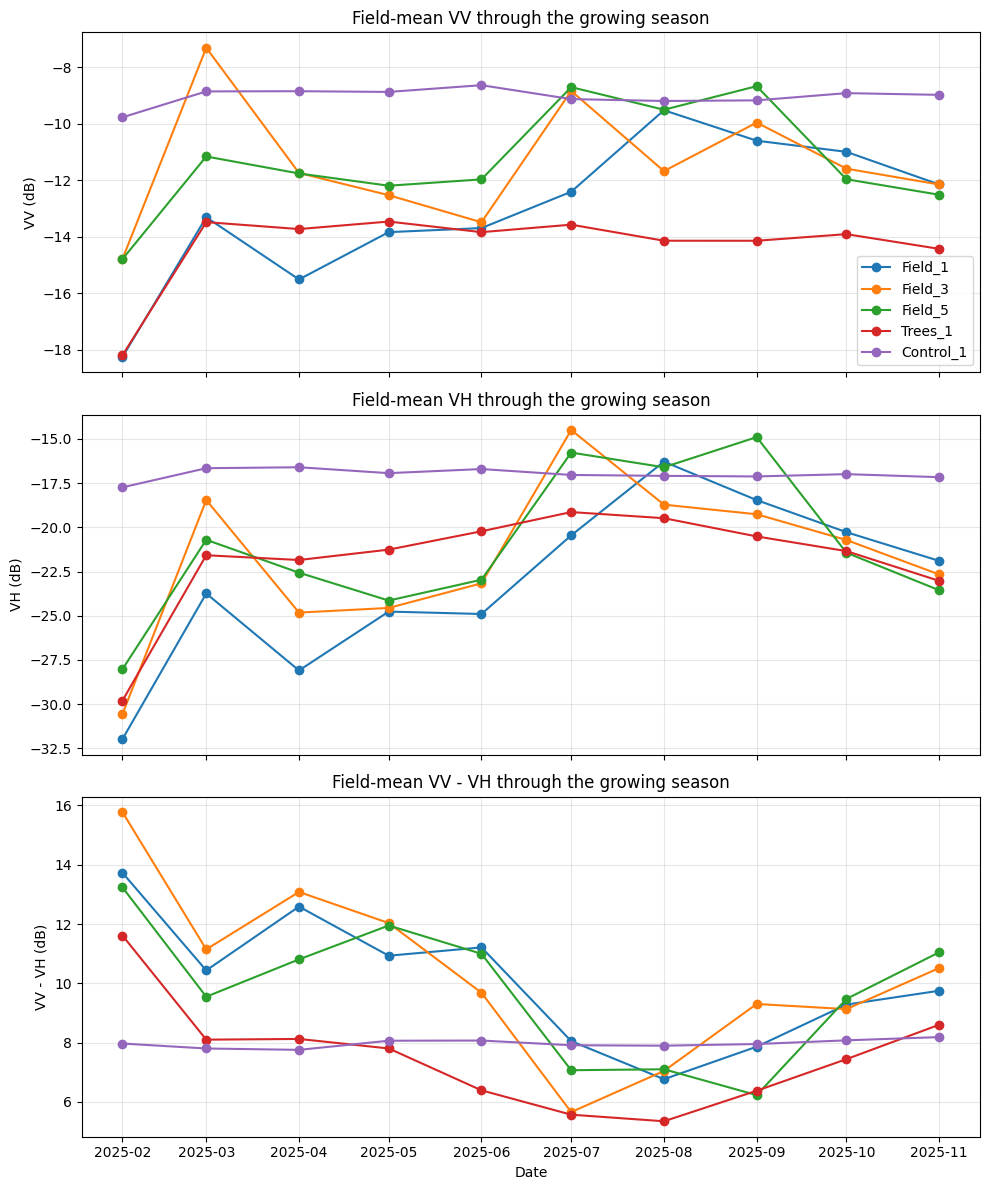

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# I chose only few of the fields, because plotting all of them makes the graphs very busy and hard to read
chosen_rois = ["Field_1", "Field_3", "Field_5", "Trees_1", "Control_1"]

for name in chosen_rois:
    if name in ts_dict:
        df = ts_dict[name]
        axes[0].plot(df["date"], df["VV"], marker="o", label=name)
        axes[1].plot(df["date"], df["VH"], marker="o", label=name)
        axes[2].plot(df["date"], df["VV_minus_VH"], marker="o", label=name)

axes[0].set_title("Field-mean VV through the growing season")
axes[0].set_ylabel("VV (dB)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Field-mean VH through the growing season")
axes[1].set_ylabel("VH (dB)")
axes[1].grid(True, alpha=0.3)

axes[2].set_title("Field-mean VV - VH through the growing season")
axes[2].set_ylabel("VV - VH (dB)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()


## 10. Build a simple crop-growth metric

Next I want you to propose a metric that captures crop development.

Possible first ideas include:

- peak VH minus spring VH,
- July VH minus April VH,
- maximum seasonal VV-VH range,
- cumulative increase from planting to peak growth.

Below is one simple example:

\[
Growth Metric = VH_{peak} - VH_{early}
\]

This is not necessarily the best metric — it is just a starting point.



,ROI,early_date,peak_month,VH_early,VH_peak,VV_early,VV_peak,VH_range,VV_minus_VH_range,growth_metric
0,Field_3,2025-02-01,7,-30.554216,-14.493032,-14.780167,-7.309841,16.061184,10.118266,10.118266
1,Field_5,2025-02-01,9,-28.021294,-14.896315,-14.785515,-8.668126,13.124979,7.007590,7.007590
2,Field_1,2025-02-01,8,-31.974320,-16.284417,-18.245316,-9.518987,15.689903,6.963574,6.963574
3,Trees_1,2025-02-01,7,-29.798650,-19.136361,-18.187000,-13.457410,10.662290,6.265638,6.265638
4,Control_1,2025-02-01,4,-17.737371,-16.601365,-9.769007,-8.633052,1.136006,0.430614,0.430614


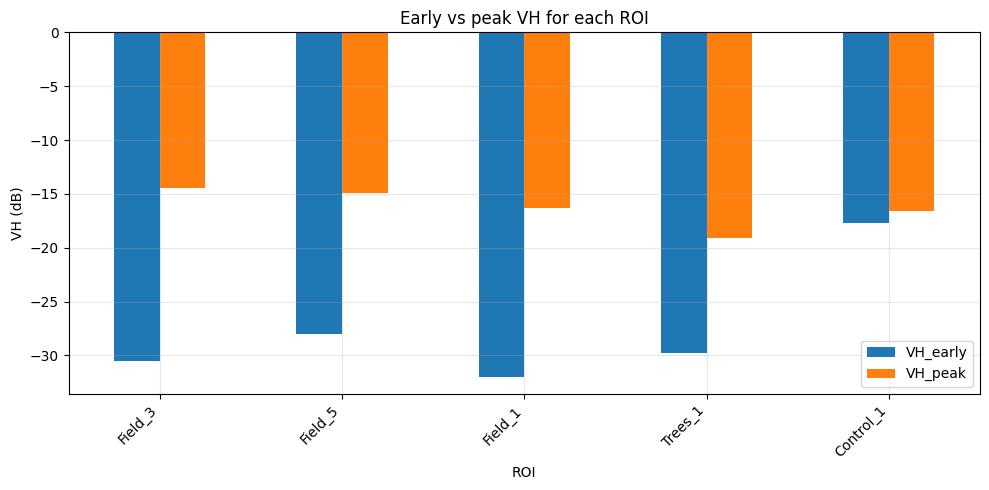

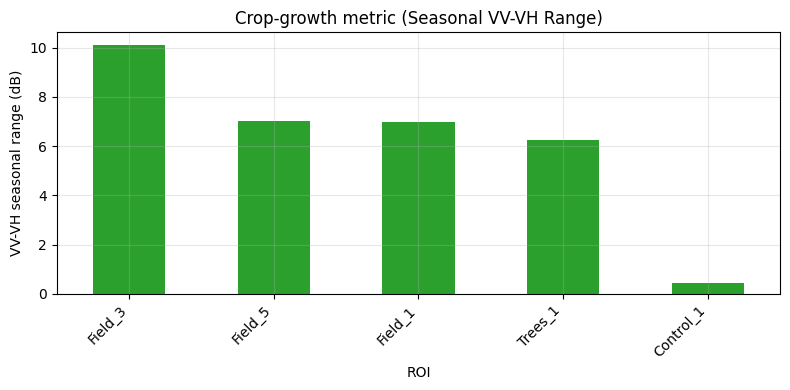

In [34]:
metrics = []

for name, df in ts_dict.items():
    if name not in chosen_rois or df.empty:
        continue

    df = df.sort_values("date").reset_index(drop=True)
    vh_early = df.loc[df["date"] == df["date"].min(), "VH"].iloc[0]
    vh_peak = df["VH"].max()
    vv_early = df.loc[df["date"] == df["date"].min(), "VV"].iloc[0]
    vv_peak = df["VV"].max()
    vh_min = df["VH"].min()
    vv_minus_vh_min = df["VV_minus_VH"].min()
    vv_minus_vh_max = df["VV_minus_VH"].max()
    growth_metric = vv_minus_vh_max - vv_minus_vh_min
    peak_month = int(df.loc[df["VH"].idxmax(), "month"])

    metrics.append({
        "ROI": name,
        "early_date": df["date"].min(),
        "peak_month": peak_month,
        "VH_early": vh_early,
        "VH_peak": vh_peak,
        "VV_early": vv_early,
        "VV_peak": vv_peak,
        "VH_range": vh_peak - vh_min,
        "VV_minus_VH_range": vv_minus_vh_max - vv_minus_vh_min,
        "growth_metric": growth_metric
    })

metrics_df = pd.DataFrame(metrics)
if not metrics_df.empty:
    metrics_df = metrics_df.sort_values("growth_metric", ascending=False).reset_index(drop=True)
    display(metrics_df)

    fig, ax = plt.subplots(figsize=(10, 5))
    metrics_df.plot(x="ROI", y=["VH_early", "VH_peak"], kind="bar", ax=ax)
    ax.set_ylabel("VH (dB)")
    ax.set_title("Early vs peak VH for each ROI")
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    metrics_df.plot(x="ROI", y="growth_metric", kind="bar", ax=ax, legend=False, color="tab:green")
    ax.set_ylabel("VV-VH seasonal range (dB)")
    ax.set_title("Crop-growth metric (Seasonal VV-VH Range)")
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No metrics were computed because ts_dict is empty or contains no valid time series.")

## 11. Optional: compare fields spatially for one month

It is often useful to look at the mapped field values in the month of strongest contrast.

This can help connect your field-average statistics back to the actual imagery.


In [35]:
img_july = monthly_composite(YEAR, 7, aoi)

m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_july.select("VV"), vv_vis, "VV July")
m.addLayer(img_july.select("VH"), vh_vis, "VH July")
m.addLayer(img_july.select("VV_minus_VH"), ratio_vis, "VV-VH July")

for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)

m

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## 12. Optional: identify likely tall vs shorter crops

With Sentinel-1 alone, you should not make an overconfident crop-type classification.  
But you can propose that one field is more consistent with a tall, strongly volume-scattering canopy than another.

For example:
- stronger seasonal VH increase,
- larger mid-season drop in VV-VH,
- more pronounced growth curve.


## Final note
This lab is designed to connect a simple SAR observable to a real seasonal process.  
The goal is not perfect crop classification, but rather to help reason from:

- backscatter,
- polarization,
- time,
- and field geometry

toward a physically grounded interpretation of crop growth.
